# Freie Schwingung
## Messen der Daten
Beim Messen der Daten wurde das Drehpendel pro Messung um 90° ausgelenkt und über einen Zeitraum von 20 Sekunden mit einer speziellen Messsoftware aufgezeichnet. DIe Dämpfung des Drehpendes wurde mithilfe zwei Spulen realisiert, somit war die Dämpfung abhängig von der Stromstärke $I$ die durch die Spuelen floss. Die Messungen wurden bei $0.3$ A angefangen und in $0.1$ A Schritten bis $1.2$ A durchgeführt. Da ab $0.5$ A die Dämpfung so stark war, dass die Schwingung nach 10 Skunden nicht mehr vorhaden war, wurde ab $0.5$ A der Zeitraum der Messungen von 20 Sekunden auf 10 verkürzt.

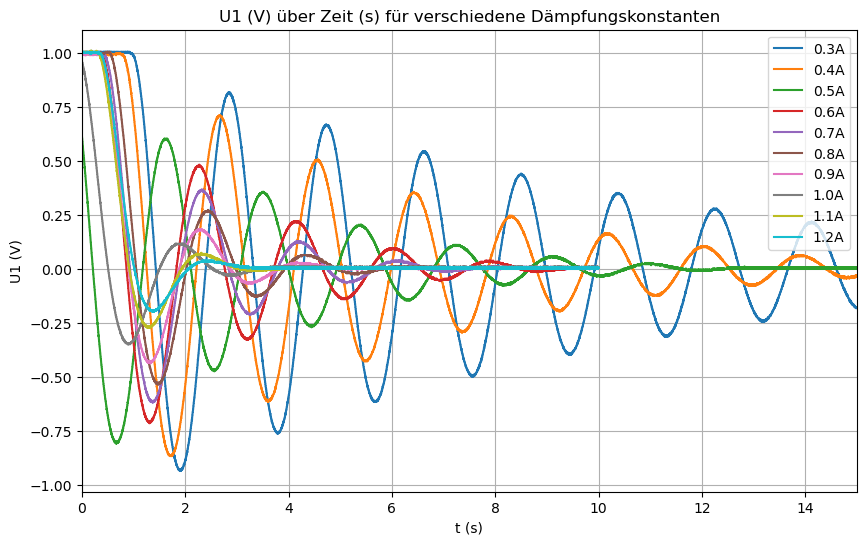

In [2]:
# Plot mit allen Daten von den verschiedenen Dämpfungskonstanten
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Daten einlesen
# Daten aus allen Dateien im Ordner "M10_Aufgabe_1_Daten" einlesen

folder_path = "M10_Aufgabe_1_Daten"
file_names = [f"{i}A_Aufgabe_1_M10.txt" for i in ["0_3", "0_4", "0_5", "0_6", "0_7", "0_8", "0_9", "1_0", "1_1", "1_2"]]

data_frames = []
for file_name in file_names:
    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path, sep='\t', names=["t (s)", "U1(V)"], skiprows=1)
    data_frames.append(df)

plt.figure(figsize=(10, 6))
[plt.plot(data_frames[i]["t (s)"], data_frames[i]["U1(V)"], label=f"{(0.3 + 0.1 * i):.1f}A") for i in range(0, len(data_frames))]
plt.xlim(0, 15)
plt.xlabel("t (s)")
plt.ylabel("U1 (V)")
plt.title("U1 (V) über Zeit (s) für verschiedene Dämpfungskonstanten")
plt.grid()
plt.legend()
plt.show()

## Bestimmung der Frequenz $f_d$ und der Abklingkonstante $\delta$
Um die Frequenz $f_d$ und die Abklingkonstante $\delta$ zu bestimmen, wird jede einzelne Schwingung mit einer Fourieranalyse zerlegt. Der Hauptpeak ist die Frequenz $f_d$. Die Abklingkonstante wird über das logarithmische Dekrement bestimmt.
$$\Lambda  = \delta T_d = ln \left( \frac{\phi (t)}{\phi (t + T_d)} \right)$$
Wobei $T_d = 1/ f_d $ die Periodendauer ist.

Wie in der [Abbildung @fig-plot-fft] zu sehen ist, haben alle Plots, ähnliche Werte. Um Messfehler zu minimieren, werden alle Peaks der Plots gemittelt.
$$f_d = \sum_{i}f_{\text{i-te peak}}$$
So kommt eine auf eine gemittelte Aplitude von $f_d = 0.49$ Hz. So folgt eine Kreisfrequenz von $ \omega_d = 2\pi \cdot f_d \approx 3.08$ rad/s.
Das logarithmisches Dekrement wird nach $\delta$ umgestellt, so kommt man auf:
$$\delta = \frac{1}{T_d} ln \left( \frac{\phi (t)}{\phi (t + T_d)} \right)=f_d \cdot ln \left( \frac{\phi (t)}{\phi (t + T_d)} \right)$$

Es gilt $\phi(t) = 1$, da das Pendel immer um 90° ausgelenkt wurde was einem Messwert von 1V entsprach. Bei $\phi(t + T_d)$ wird die Amplitude graphisch ermittelt und das logarithmische Dekrement wird für alle Messungen bestimmt. Die Werte sind in der [Tabelle @fig-tab-plot-fft] zu finden.

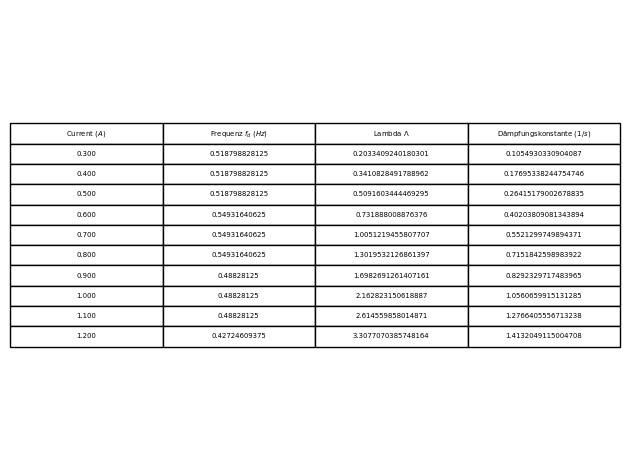

In [15]:
# | label: fig-tab-plot-fft
# | fig-cap: Tabelle der bestimmten Dämpfungskonstanten für die verschiedene Messungen
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

f_d = peaks_amp

# Händsich ausgelesen :/

# [0] => 1th Peak at 0.3A # [1] => 1th Peak at 0.4A etc.
peak_1 = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
# [0] => 2th Peak at 0.3A # [1] => 2th Peak at 0.4A etc.
peak_2 = np.array([0.816, 0.711, 0.601, 0.481, 0.366, 0.272, 0.183, 0.115, 0.0732, 0.0366])

_lambda = np.log(peak_1 / peak_2)

damping_constant = [_lambda[i] * f_d[i] for i in range(0, len(_lambda))]

#print(damping_constant)

# Create a table with the damping constants
fig, ax = plt.subplots()

# hide axes
fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')

# Lambda, damping constant, and the current
damping_constant_table = pd.DataFrame({
    "Current ($A$)": [f"{(0.3 + 0.1 * i):.3f}" for i in range(0, len(data_frames))],
    "Frequenz $f_d$ ($Hz$)": [f"{f_d[i]}" for i in range(0, len(data_frames))],
    "Lambda $ \\Lambda $": _lambda,
    "Dämpfungskonstante ($1/s$)": damping_constant,
})

ax.table(cellText=damping_constant_table.values, colLabels=damping_constant_table.columns, loc='center', cellLoc='center')

fig.tight_layout()

plt.show()




Standardabweichung für 1_2A_Aufgabe_1_M10.txt: 0.0382 Hz


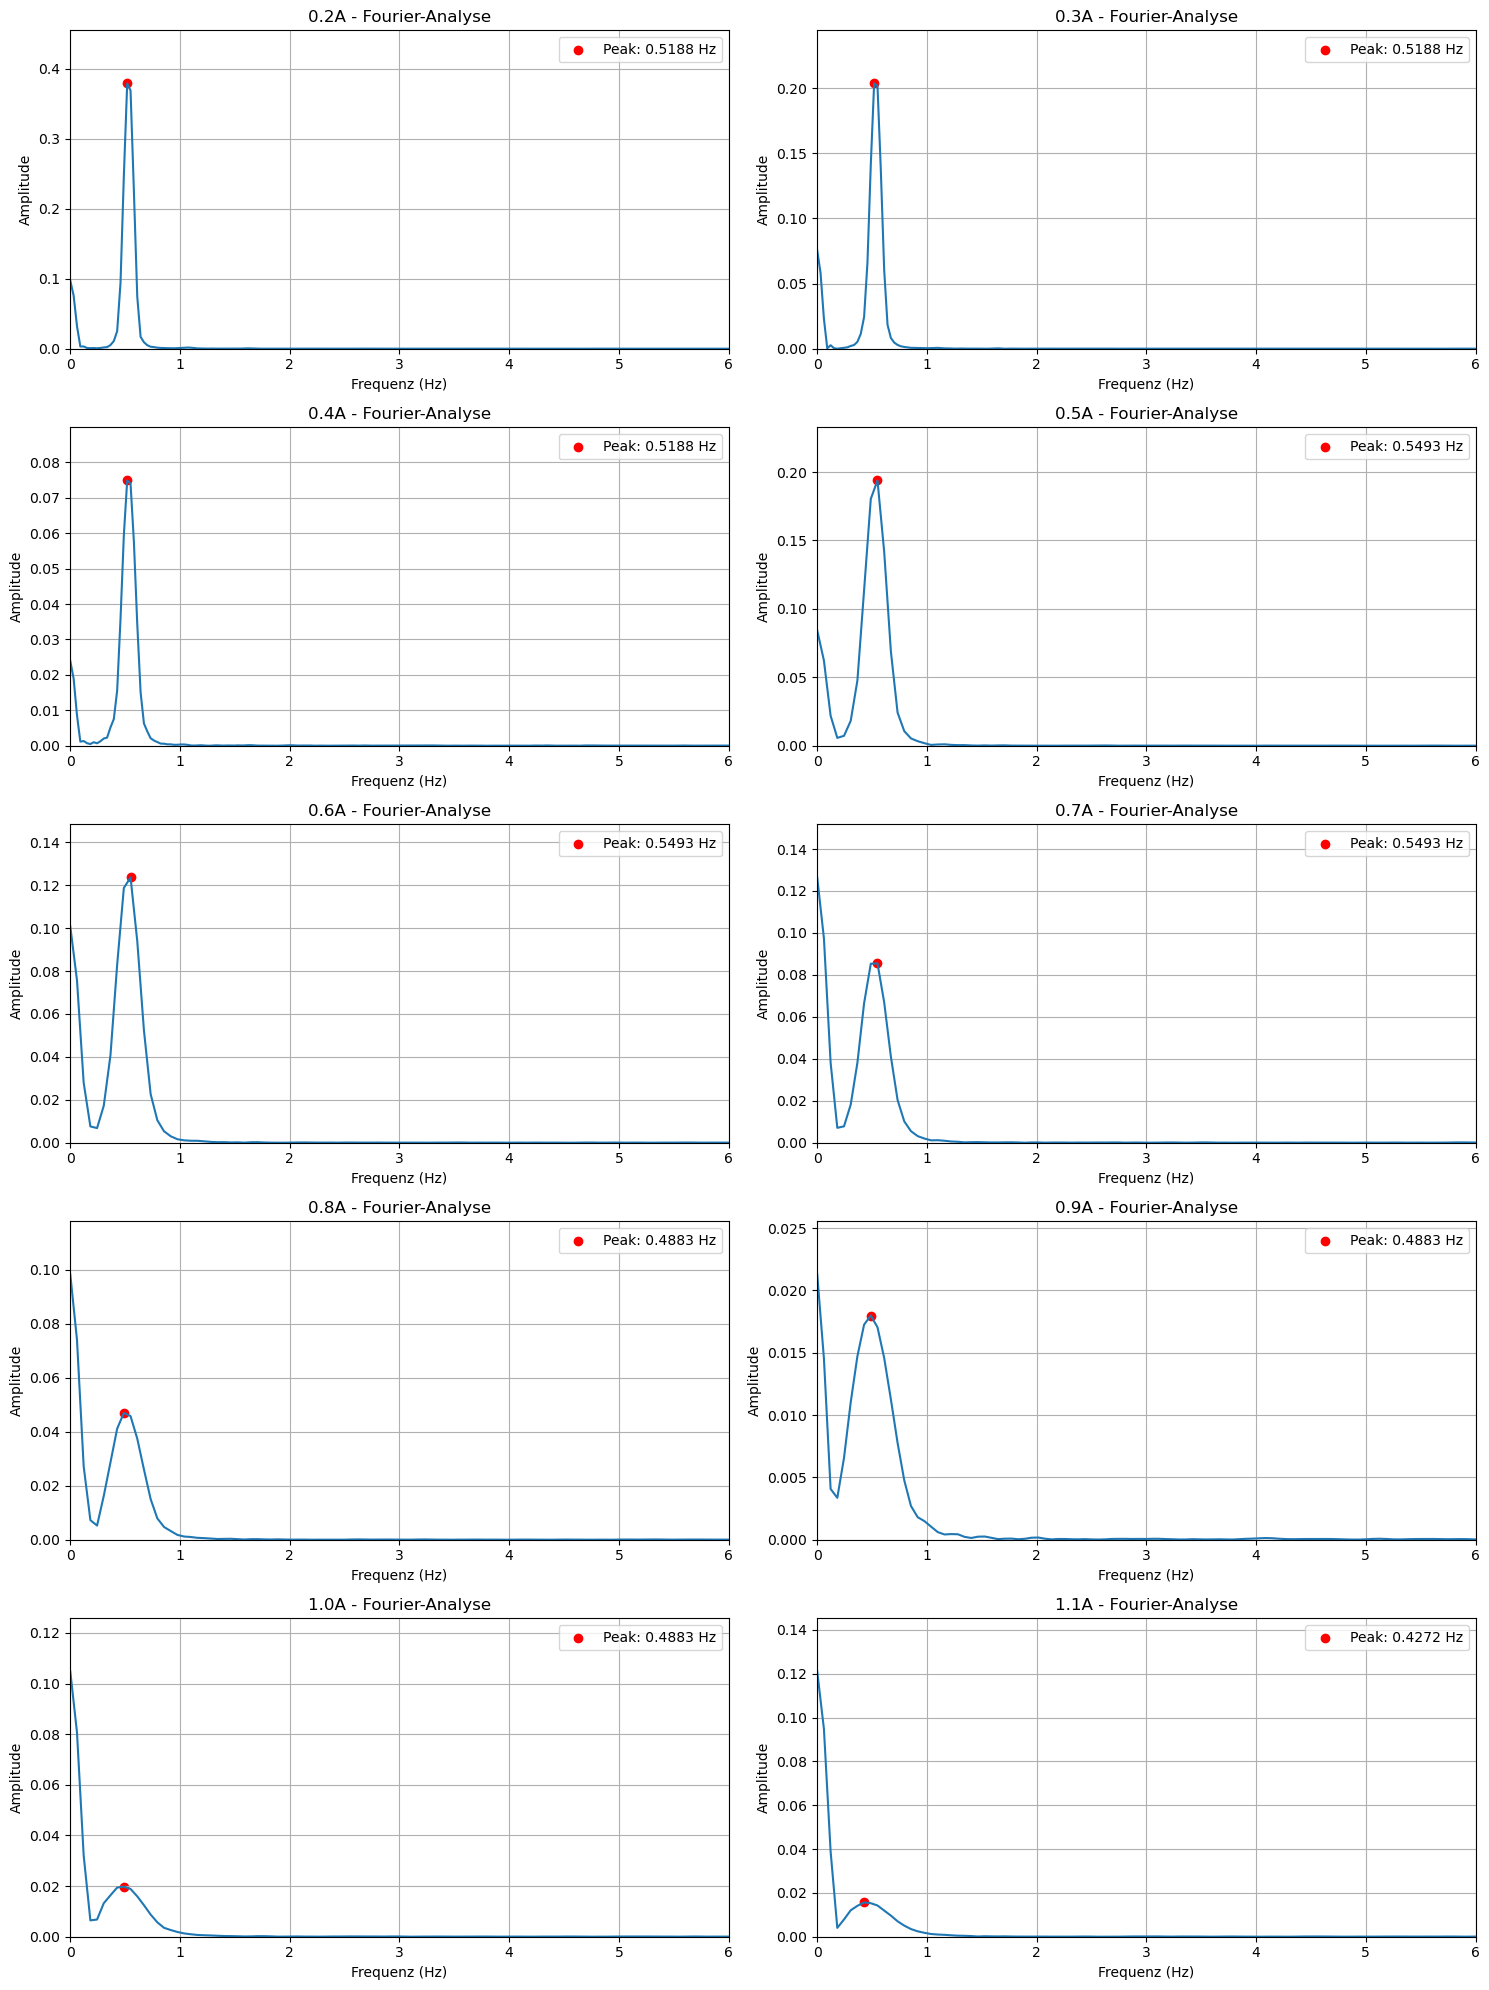

In [ ]:
# | label: fig-plot-fft
# | fig-cap: Fourier-Analyse der Messungen
from scipy.fft import fft, fftfreq
# Plot mit allen Daten von den verschiedenen Dämpfungskonstanten
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.signal import find_peaks

# Daten einlesen
# Daten aus allen Dateien im Ordner "M10_Aufgabe_1_Daten" einlesen

folder_path = "M10_Aufgabe_1_Daten"
file_names = [f"{i}A_Aufgabe_1_M10.txt" for i in ["0_3", "0_4", "0_5", "0_6", "0_7", "0_8", "0_9", "1_0", "1_1", "1_2"]]

data_frames = []
for file_name in file_names:
    file_path = os.path.join(folder_path, file_name)
    df = pd.read_csv(file_path, sep='\t', names=["t (s)", "U1(V)"], skiprows=1)
    data_frames.append(df)

peaks_amp = np.array([])

# Subplot erstellen
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

# Fourier-Analyse und Plot für jede Datei
for i, df in enumerate(data_frames):
    # Zeit- und Spannungsdaten extrahieren
    t = df["t (s)"].values
    U = df["U1(V)"].values

    # Signal zentrieren
    U_centered = U - np.mean(U)
    
    # Fensterfunktion anwenden (Hann-Fenster) für bessere Frequenzauflösung
    window = np.hanning(len(U_centered))
    U_win = U_centered * window

    # FFT mit Zero-Padding zur verbesserten Auflösung
    N = len(t)
    T = t[1] - t[0]  # Abtastintervall
    N_fft = 2 ** int(np.ceil(np.log2(N)))  # nächsthöhere Zweierpotenz
    yf = fft(U_win, n=N_fft)
    xf = fftfreq(N_fft, T)[:N_fft // 2]  # Frequenzen

    # Amplitudenspektrum berechnen; Normierung angepasst an das Fenster
    amplitude = 2.0 / np.sum(window) * np.abs(yf[:N_fft // 2])

    # Suche nach Peaks im Amplitudenspektrum innerhalb von 0.3 Hz bis 2 Hz
    peaks, properties = find_peaks(amplitude, prominence=0.05)
    valid_peaks = peaks[(xf[peaks] >= 0.3) & (xf[peaks] <= 2)]
    if len(valid_peaks) > 0:
        peak_idx = valid_peaks[np.argmax(amplitude[valid_peaks])]
        peak_freq = xf[peak_idx]
        peak_amp = amplitude[peak_idx]
    else:
        # Fallback: größter Wert im definierten Frequenzbereich
        mask = (xf >= 0.3) & (xf <= 2)
        if np.any(mask):
            peak_idx = np.argmax(amplitude[mask])
            peak_freq = xf[mask][peak_idx]
            peak_amp = amplitude[mask][peak_idx]
        else:
            # Falls keine Frequenzen vorhanden sind, verwende den globalen Maximalwert
            peak_idx = np.argmax(amplitude)
            peak_freq = xf[peak_idx]
            peak_amp = amplitude[peak_idx]

    # Calculate the Error
    peaks_amp = np.append(peaks_amp, peak_freq)
    #print(f"Peak Frequency for {file_names[i]}: {peak_freq:.4f} Hz, Error: {error:.2f}%")
    
    # Plot der Fourier-Analyse
    axes[i].plot(xf, amplitude)
    axes[i].scatter(peak_freq, peak_amp, color='red', label=f'Peak: {peak_freq:.4f} Hz')
    axes[i].set_title(f"{(0.3 + 0.1 * (i-1)):.1f}A - Fourier-Analyse")
    axes[i].set_xlabel("Frequenz (Hz)")
    axes[i].set_ylabel("Amplitude")
    axes[i].set_xlim(0, 6)
    axes[i].set_ylim(0, 1.2 * np.max(amplitude))
    axes[i].grid()
    axes[i].legend()

# Berchnung der Standartabweichung
mean = np.mean(peaks_amp)
std = np.sqrt(np.sum((peaks_amp - mean) ** 2/(len(peaks_amp) - 1)))
print(f"Standardabweichung: {std:.4f} Hz")



# Layout anpassen und anzeigen
plt.tight_layout()
plt.show()


## $\omega_d$ als Funktion von $\delta$

Um die Funktion zu plotten muss bei dieser Aufgaben $\omega_d$ berechnet werden. Dies berechnet sich wie folgt.
$$\omega_d = \sqrt{\omega_0^2 - \delta^2}$$
FÜr den theoretischen Wert wird als $\omega_d$ der Median der gemessenen gedämpften Eigenfrequenzen. Weshalb wie in [Abbildung @fig-omega-over-delta] einige Werte sehr nah bei dem theoretsichen Wert liegen währen andere weiter weg liegen. Aber man kann trotzdem ganz gut sehen dass die gemessenen Werte der theoretischen Kurve folgen. Das sieht man besonders gut bei den Werten die in der nähe von der theoretischen Kurve liegen.

Mittlere ungedämpfte Eigenfrequenz ω₀: 3.2021848947112757


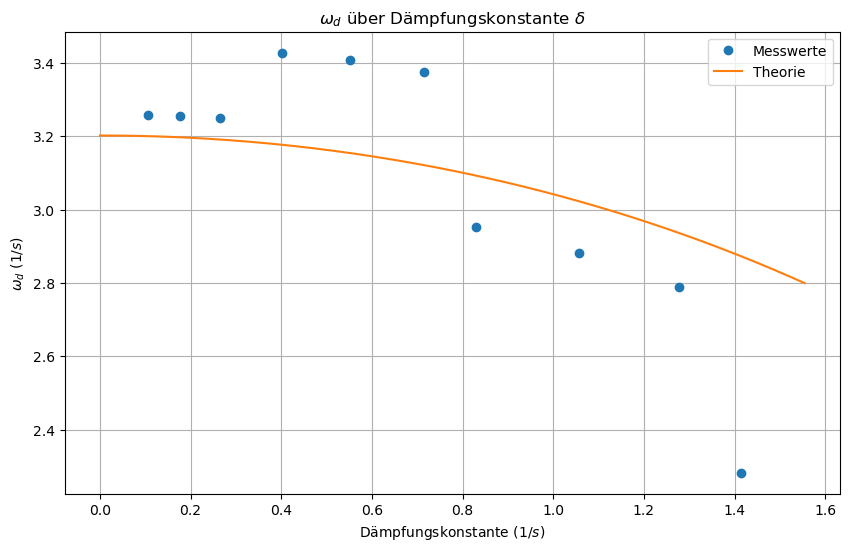

In [18]:
# | label: fig-omega-over-delta
# | fig-cap: Plot von Omega über Delta
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


f_d = peaks_amp
omega_0 = f_d * 2 * np.pi

# [0] => 1th Peak at 0.3A # [1] => 1th Peak at 0.4A etc.
peak_1 = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
# [0] => 2th Peak at 0.3A # [1] => 2th Peak at 0.4A etc.
peak_2 = np.array([0.816, 0.711, 0.601, 0.481, 0.366, 0.272, 0.183, 0.115, 0.0732, 0.0366])

_lambda = np.log(peak_1 / peak_2)

damping_constant = [_lambda[i] * f_d[i] for i in range(0, len(_lambda))]

damping_constant = np.array([_lambda[i] * f_d[i] for i in range(len(_lambda))])
# Calculate omega_d ensuring sqrt argument is non-negative
diff = omega_0**2 - damping_constant**2
omega_d = np.sqrt(np.where(diff < 0, 0, diff))
omega_d_mean = np.mean(omega_0)
print("Mittlere ungedämpfte Eigenfrequenz ω₀:", omega_d_mean)

# Theoriekurve berechnen
delta_vals = np.linspace(0, max(damping_constant) * 1.1, 200)
omega_d_theorie = np.sqrt(np.maximum(omega_d_mean**2 - delta_vals**2, 0))

#plotten
plt.figure(figsize=(10, 6))
plt.plot(damping_constant, omega_d, 'o', label="Messwerte")
plt.plot(delta_vals, omega_d_theorie, '-', label="Theorie")
plt.xlabel("Dämpfungskonstante ($1/s$)")
plt.ylabel("$ω_d$ ($1/s$)")
plt.title("$ω_d$ über Dämpfungskonstante $\\delta$")
plt.grid()
plt.legend()
plt.show()



